#  Ghép ảnh toàn cảnh (Panoramic Photos– Image Stitching)

## Pipeline
- Load và tiền xử lý ảnh (chuyển ảnh xám, chuẩn hóa kích thước nếu cần).
- Trích xuất đặc trưng (feature detection và description).
- So khớp đặc trưng giữa các cặp ảnh.
- Ước lượng phép biến đổi hình học (homography) giữa các ảnh.
- Căn chỉnh ảnh và ghép ảnh để tạo panorama.
- Xửlý vùng chồng lấn và biên ảnh (blending) ở mức cơ bản.

## Load và tiền xử lý ảnh

### Import

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import requests

image_folder = "images"

if not os.path.exists(image_folder):
    os.makedirs(image_folder)
    print(f"Created folder: {image_folder}")

Created folder: images


### Load ảnh
Load 3 ảnh chụp cùng một cảnh vào

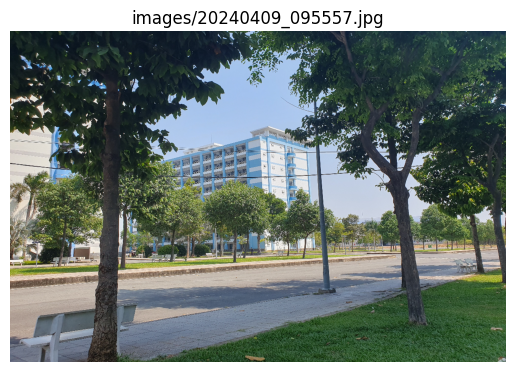

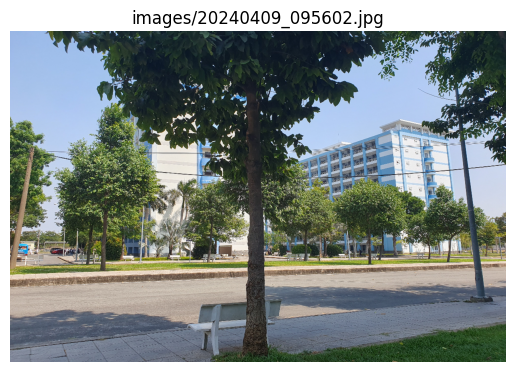

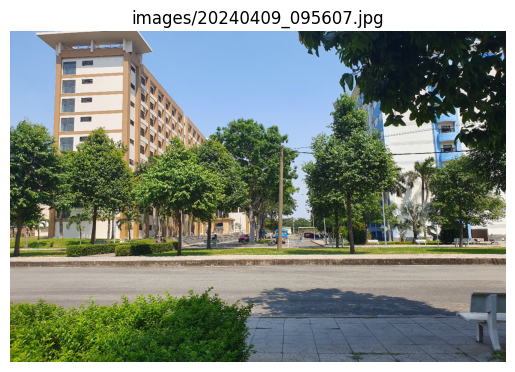

In [2]:
image_paths = [
    "images/20240409_095557.jpg",
    "images/20240409_095602.jpg",
    "images/20240409_095607.jpg",
    #"images/20240409_095613.jpg"
]

images = []
grays = []

for path in image_paths:
    img = cv2.imread(path)
    img = cv2.resize(img, (1200, 800))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.imshow(img)
    plt.title(path)
    plt.axis("off")

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    images.append(img)
    grays.append(gray)

## FEATURE EXTRACTION
Trích xuất đặc trưng

In [3]:
def extract_features(gray, method):
    if method == "SIFT":
        detector = cv2.SIFT_create()
    elif method == "BRISK":
        detector = cv2.BRISK_create()

    kp, des = detector.detectAndCompute(gray, None)
    return kp, des

## FEATURE MATCHING
So khớp đặc trưng giữa các cặp ảnh

In [4]:
def match_features(des1, des2, method):

    if method in ["BRISK"]:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    else:
        bf = cv2.BFMatcher(cv2.NORM_L2)

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

## TÍNH HOMOGRAPHY
Ước lượng phép biến đổi hình học giữa các ảnh.

In [5]:
def compute_homography(kp1, kp2, matches):

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    return H

## WARP + STITCH
Căn chỉnh ảnh và ghép ảnh để tạo panorama

In [6]:
def warp_and_stitch(img1, img2, H):

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    result = cv2.warpPerspective(img1, H, (w1 + w2, max(h1, h2)))

    result[0:h2, 0:w2] = img2

    return result

## BLENDING (cơ bản)
Xử lý vùng chồng lấn và biên ảnh ở mức cơ bản.

In [7]:
def simple_blending(result, img2):

    h2, w2 = img2.shape[:2]

    mask = (result[0:h2, 0:w2] == 0)
    result[0:h2, 0:w2][mask] = img2[mask]

    return result

## Ghép Ảnh
Hàm gọi để xử lý ảnh theo pipeline

In [8]:
def panorama(images, method):

    pano = images[0]

    for i in range(1, len(images)):

        gray1 = cv2.cvtColor(pano, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY)

        # 1. Feature
        kp1, des1 = extract_features(gray1, method)
        kp2, des2 = extract_features(gray2, method)

        # 2. Matching
        matches = match_features(des1, des2, method)

        if len(matches) < 5:
            print("Not enough matches")
            continue

        # 3. Homography
        H = compute_homography(kp1, kp2, matches)

        # 4. Warp + Stitch
        pano = warp_and_stitch(pano, images[i], H)

        # 5. Blending
        pano = simple_blending(pano, images[i])

    return pano

## Chạy 2 Phương Pháp
Chạy để xử lý theo 2 phương pháp **SIFT** và **BRISK**

In [9]:
pano_sift = panorama(images, "SIFT")
pano_brisk  = panorama(images, "BRISK")

## Hiển Thị
Show kết quả đã ghép

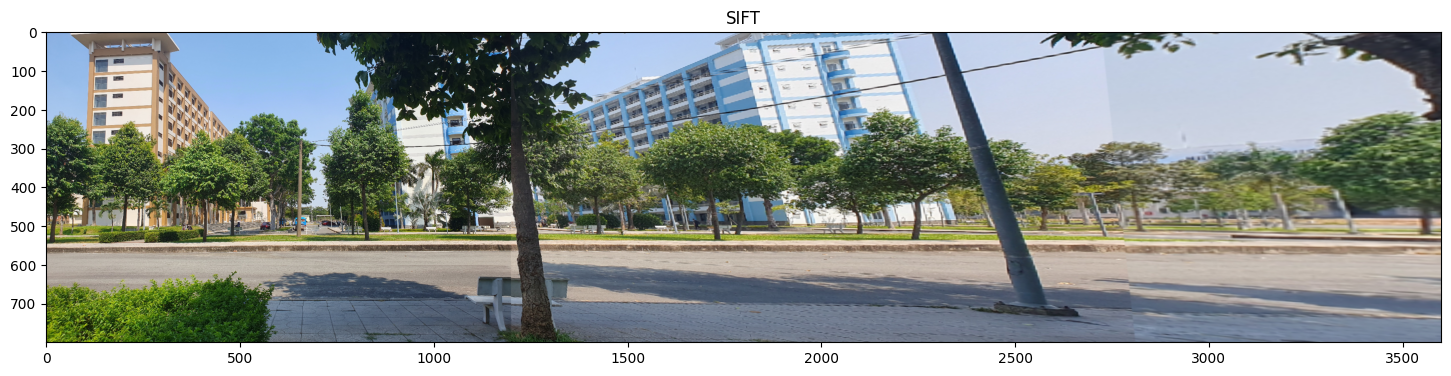

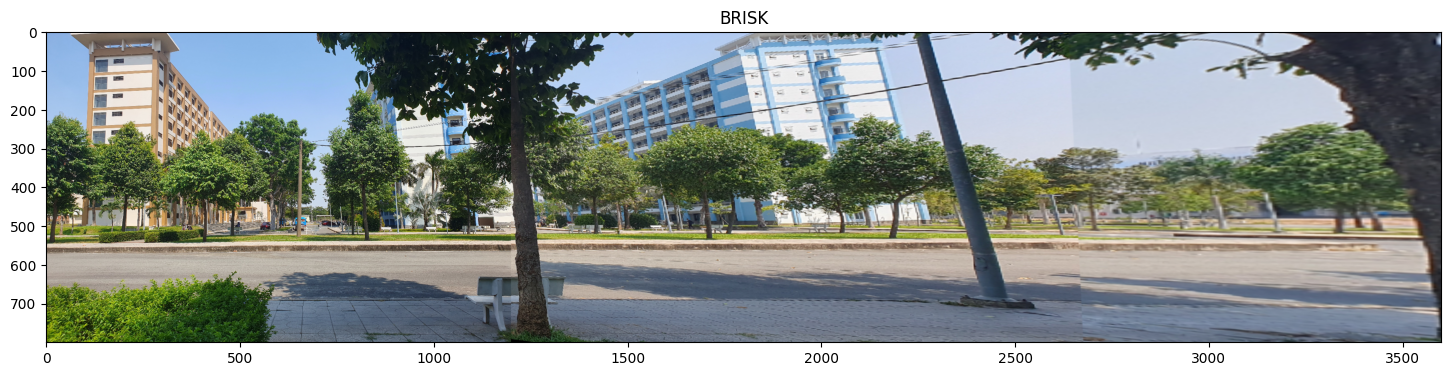

In [11]:
plt.figure(figsize=(18,6))
plt.imshow(pano_sift)
plt.title("SIFT")
plt.show()

plt.figure(figsize=(18,6))
plt.imshow(pano_brisk)
plt.title("BRISK")
plt.show()

## So sánh kết quả ghép ảnh giữa các phương pháp (SIFT và BRISK):
### So sánh kết quả ghép ảnh giữa các phương pháp (SIFT và BRISK):
- SIFT: Cho thấy độ chính xác căn chỉnh rất cao. Các đường thẳng của tòa nhà (đặc biệt là tòa nhà màu xanh ở giữa) và vỉa hè được khớp nối một cách tự nhiên. SIFT nổi tiếng với khả năng xử lý tốt các thay đổi về tỷ lệ và góc xoay, điều này thể hiện rõ qua cấu trúc hình học của các vật thể không bị biến dạng tại điểm giao thoa.

- BRISK: Độ chính xác căn chỉnh cũng khá tốt, nhưng nếu quan sát kỹ các chi tiết nhỏ ở các điểm nối (seams), có thể thấy độ khớp đôi khi không "mượt" bằng SIFT. Tuy nhiên, trong bài toán này, BRISK đã hoàn thành rất tốt nhiệm vụ giữ cho các tòa nhà đứng thẳng và đúng vị trí.
### Độ chính xác căn chỉnh
- SIFT: Tính liên tục rất ấn tượng. Bạn có thể nhìn vào các đường dây điện chạy ngang phía trên hoặc đường chân trời; chúng gần như không bị ngắt quãng hay có hiện tượng "bóng ma" (ghosting). Các điểm nối giữa các ảnh thành phần được xử lý mượt mà, tạo cảm giác như một bức ảnh chụp duy nhất.

- BRISK: Có xuất hiện một vài điểm thiếu liên tục nhẹ. Đặc biệt, hãy quan sát phần tán cây và mặt đường ở các vị trí ghép nối. Có những vệt ghép nối hơi lộ rõ hơn so với SIFT, khiến bức ảnh trông như các mảnh ghép được đặt cạnh nhau thay vì hòa quyện hoàn toàn.
### Tính liên tục của ảnh
- SIFT:

Ưu điểm: Bức ảnh trông tự nhiên, độ tương phản và màu sắc đồng đều giữa các vùng ghép. Không có hiện tượng biến dạng hình học nghiêm trọng.

Nhược điểm: Thuật toán này thường tốn nhiều tài nguyên tính toán hơn.

- BRISK:

Ưu điểm: Kết quả đạt mức 9/10 so với SIFT nhưng thường có tốc độ xử lý nhanh hơn nhiều (đặc biệt hữu ích cho thiết bị di động).

Nhược điểm: Tại một số khu vực có chi tiết phức tạp như lá cây, ảnh có vẻ hơi "gãy" nhẹ hoặc xuất hiện sự sai lệch nhỏ về độ sáng tại biên giới ghép nối, tạo cảm giác hơi gắt về mặt thị giác.